In [1]:
import numpy as np
import pandas as pd

In [90]:
df = pd.read_csv('imdb_top_5000_tv_shows.csv')
df

,tconst,primaryTitle,startYear,endYear,rank,averageRating,numVotes,directors,writers,genres,IMDbLink,Title_IMDb_Link
0,tt0903747,Breaking Bad,2008,2013.0,1,9.5,2312017,"Michelle MacLaren, Adam Bernstein, Vince Gilli...","Vince Gilligan, Peter Gould, George Mastras, S...","Crime, Drama, Thriller","<a href=""https://www.imdb.com/title/tt0903747""...","<a href=""https://www.imdb.com/title/tt0903747""..."
1,tt0185906,Band of Brothers,2001,2001.0,2,9.4,559065,"David Frankel, Mikael Salomon, Tom Hanks, Davi...","Stephen Ambrose, Erik Bork, E. Max Frye, Tom H...","Action, Drama, History","<a href=""https://www.imdb.com/title/tt0185906""...","<a href=""https://www.imdb.com/title/tt0185906""..."
2,tt7366338,Chernobyl,2019,2019.0,3,9.3,942083,Johan Renck,Craig Mazin,"Drama, History, Thriller","<a href=""https://www.imdb.com/title/tt7366338""...","<a href=""https://www.imdb.com/title/tt7366338""..."
3,tt0795176,Planet Earth,2006,2006.0,4,9.4,226878,"Alastair Fothergill, Mark Linfield","David Attenborough, Vanessa Berlowitz, Alastai...","Documentary, Family","<a href=""https://www.imdb.com/title/tt0795176""...","<a href=""https://www.imdb.com/title/tt0795176""..."
4,tt5491994,Planet Earth II,2016,2016.0,5,9.4,165947,"Justin Anderson, Ed Charles, Fredi Devas, Chad...",Elizabeth White,Documentary,"<a href=""https://www.imdb.com/title/tt5491994""...","<a href=""https://www.imdb.com/title/tt5491994""..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,tt2882382,Gerçek Kesit,1993,2006.0,4996,7.9,778,-,-,"Action, Crime, Fantasy","<a href=""https://www.imdb.com/title/tt2882382""...","<a href=""https://www.imdb.com/title/tt2882382""..."
4996,tt9165752,Songland,2019,2020.0,4997,8.1,776,Ivan Dudynsky,-,Reality-TV,"<a href=""https://www.imdb.com/title/tt9165752""...","<a href=""https://www.imdb.com/title/tt9165752""..."
4997,tt0165019,The Visitors,1983,NaN,4998,8.2,774,Jindrich Polák,"Ota Hofman, Jindrich Polák","Comedy, Family, Fantasy","<a href=""https://www.imdb.com/title/tt0165019""...","<a href=""https://www.imdb.com/title/tt0165019""..."
4998,tt0456788,Karanlikta Kosanlar,2001,2001.0,4999,8.5,773,Ugur Yücel,"Defne Kayalar, Ugur Yücel, Ahmet Ümit","Crime, Drama, Mystery","<a href=""https://www.imdb.com/title/tt0456788""...","<a href=""https://www.imdb.com/title/tt0456788""..."


#### EDA Steps 

1. Basic Information
What is the shape of the dataset? (i.e., how many rows and columns are there?)

What are the column names and their data types?

Are there any missing values in the dataset?

2. Statistical Summary
What are the basic statistics for numerical columns? (mean, median, min, max, etc.)

Are there any outliers in the data?

3. Data Cleaning
Do any columns need to be renamed for clarity?

Are there any duplicate rows?

How will you handle missing values—drop or fill?

4. Categorical Data
What are the unique values in each categorical column?

What is the frequency distribution of those values?

5. Numerical Data
What is the distribution of numerical features?

Are there any correlations between numerical columns?

6. Date/Time Columns
Are there any date columns? If yes, are they in datetime format?

Can you extract useful information like year, month, day, or weekday?

7. Feature Engineering
Can you create new columns that might be useful for analysis?

8. Data Visualization (with Seaborn/Matplotlib if needed)
Can you visualize distributions using histograms or boxplots?

Can you identify relationships using scatter plots or pair plots?

Are there trends over time (if time data exists)?

#### Finding Shape of the data set which means how many row and column are there 

In [6]:
print("Row : ",df.shape[0])
print("Columns : ",df.shape[1])

Row :  5000
Columns :  12


#### Here we check types of column for knowing which column contain numerical contex

In [9]:
df.dtypes

tconst              object
primaryTitle        object
startYear            int64
endYear            float64
rank                 int64
averageRating      float64
numVotes             int64
directors           object
writers             object
genres              object
IMDbLink            object
Title_IMDb_Link     object
dtype: object

#### Now we check missing values in Data 

In [ ]:
df.isna().sum()
# so only 'endYear' column only contain null values it is : 885  

tconst               0
primaryTitle         0
startYear            0
endYear            885
rank                 0
averageRating        0
numVotes             0
directors            0
writers              0
genres               0
IMDbLink             0
Title_IMDb_Link      0
dtype: int64

i am filling 'Ongoing' String at null value because it make sense because if i am filling the same year 
that not might meaning full because it means the show in ended but that is also wrong step 
this is IMBA rating data so it's less chances to contain null value is has some sense for
contain null value so that's why i fill 'Ongaing' string instead of putting any other things 

In [ ]:
df['endYear'].fillna('Ongoing',inplace=True)

C:\Users\MAHADEV\AppData\Local\Temp\ipykernel_24712\3082240970.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ongoing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['endYear'].fillna('Ongoing',inplace=True)


Now our data is totally clean it not contain any kind of null value 

In [57]:
df.isna().sum()

tconst             0
primaryTitle       0
startYear          0
endYear            0
rank               0
averageRating      0
numVotes           0
directors          0
writers            0
genres             0
IMDbLink           0
Title_IMDb_Link    0
dtype: int64

#### Now we see the Statistical summary 

Here you can see the new import is 'TABULATE' typically tabulate is convert out data into design row and column way that means here i need statistical summary but if i directly write as 'df.describe' so it will give me normal format not a specific table format so that's why i call tablulate for table formating   

In [79]:
from tabulate import tabulate as tb

print("Only numerical columns :")
print(tb(df.describe(include='object'),headers='keys',tablefmt='grid'))
print("Include objects also ")
df.describe()

Only numerical columns :
+--------+-----------+----------------+-----------+-------------+-----------+----------+------------------------------------------------------------------------------+---------------------------------------------------------------------------------+
|        | tconst    | primaryTitle   | endYear   | directors   | writers   | genres   | IMDbLink                                                                     | Title_IMDb_Link                                                                 |
+========+===========+================+===========+=============+===========+==========+==============================================================================+=================================================================================+
| count  | 5000      | 5000           | 5000      | 5000        | 5000      | 5000     | 5000                                                                         | 5000                                                     

,startYear,rank,averageRating,numVotes
count,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2008.901800,2500.500000,8.004300,2.713506e+04
std,14.376087,1443.520003,0.438322,9.023652e+04
min,1948.000000,1.000000,7.300000,7.110000e+02
25%,2003.000000,1250.750000,7.700000,2.095500e+03
50%,2014.000000,2500.500000,8.000000,5.185000e+03
75%,2019.000000,3750.250000,8.300000,1.701000e+04
max,2025.000000,5000.000000,9.600000,2.420347e+06


Here we fin out the outliers of our dataset in contex of Number of voting and as well as here we can see i use seaborn's boxplot for easy to undertand and visulize the things 

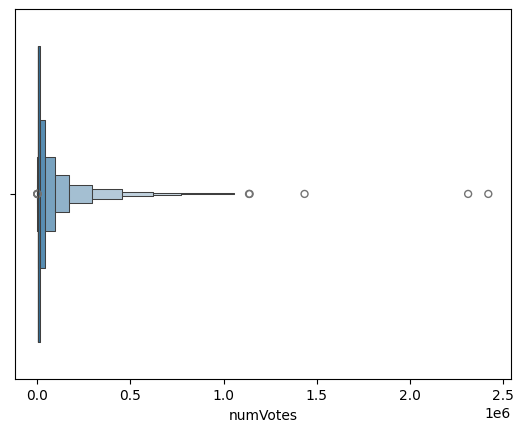

In [ ]:
import seaborn as sns

sns.boxenplot(x=df['numVotes'])
    